# Nathan Day

### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

### Problem 1 Part 1.1

In [ ]:
# 1. Evaluate (3+5)^2/7 - sqrt(10)
expr1 = (3 + 5)**2/7 - np.sqrt(10)
print("1.1 result =", expr1)

# 2. Let a=2, b=5. Compute a/b, log(b), e^a
a = 2
b = 5
print("a/b =", a/b)
print("log(b) =", np.log(b))
print("exp(a) =", np.exp(a))

# 3a. Explanation of element-wise v. dot product
print("Element-wise vs dot product:\n")

print("Element-wise operations act on corresponding entries of two vectors.")
print("Each component is combined independently to produce another vector of the same length.\n")

print("The dot product multiplies corresponding entries, then summing the results.")
print("It produces a single scalar value, not a vector like the element-wise case.\n")

# 3b. Example of the difference

# Define two vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Vector a =", a)
print("Vector b =", b)

# Element-wise
elem_mult = a * b
print("\nElement-wise multiplication a * b =", elem_mult)

# Dot product
dot_prod = np.dot(a, b)
print("Dot product a · b =", dot_prod)

1) Warm-up: arithmetic and variables
1.1 result = 5.980579482688762
a/b = 0.4
log(b) = 1.6094379124341003
exp(a) = 7.38905609893065
Element-wise vs dot product:

Element-wise operations act on corresponding entries of two vectors.
Each component is combined independently to produce another vector of the same length.

The dot product multiplies corresponding entries, then summing the results.
It produces a single scalar value, not a vector like the element-wise case.

Vector a = [1 2 3]
Vector b = [4 5 6]

Element-wise multiplication a * b = [ 4 10 18]
Dot product a · b = 32


### Problem 1 Part 1.2

In [ ]:
# 4a. Create vector w/ step size
x = np.arange(0, 2 + 1e-12, 0.1) # added a small perturbation because my code was tweaking
# 4b. Output len(x)
print("length(x) =", len(x))

# 5. Define y = sin(2πx) from 0 to 2pi
y = np.sin(2*np.pi*x)

# 5b. Report three different values
indexs = [0, len(x)//2, -1]
print("Sample y values:")

for i in indexs:
    print(f"  x[{i}]={x[i]:.2f}, y[{i}]={y[i]:.6f}")

# 5c. Max and where
imax = np.argmax(y)
print("\nmax(y) =", y[imax])
print("index of max =", imax)
print("x at max =", x[imax])

length(x) = 21
Sample y values:
  x[0]=0.00, y[0]=0.000000
  x[10]=1.00, y[10]=-0.000000
  x[-1]=2.00, y[-1]=-0.000000

max(y) = 0.9510565162951538
index of max = 12
x at max = 1.2000000000000002


### Problem 1 Part 1.3

In [ ]:
# 6. Matrices and solving linear systems

A = np.array([[2, -1],
              [1,  3]], dtype=float)
v = np.array([1, -2], dtype=float)

print("A=\n", A)
print("v=", v)

Av = A @ v
print("\nAv =", Av)

x_sol = np.linalg.solve(A, v)
print("Solution to Ax=v is x =", x_sol)

detA = np.linalg.det(A)
eigvals, eigvecs = np.linalg.eig(A)

print("\ndet(A) =", detA)
print("eigenvalues =", eigvals)
print("eigenvectors (columns)=\n", eigvecs)

A=
 [[ 2. -1.]
 [ 1.  3.]]
v= [ 1. -2.]

Av = [ 4. -5.]
Solution to Ax=v is x = [ 0.14285714 -0.71428571]

det(A) = 7.000000000000001
eigenvalues = [2.5+0.8660254j 2.5-0.8660254j]
eigenvectors (columns)=
 [[ 0.35355339-0.61237244j  0.35355339+0.61237244j]
 [-0.70710678+0.j         -0.70710678-0.j        ]]


### Problem 1 Part 1.4

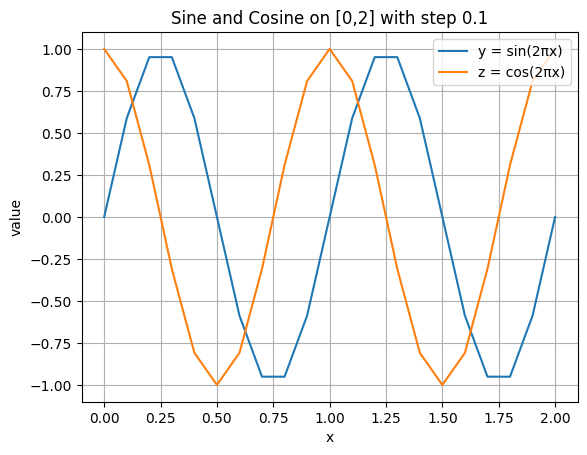

Figure 1. A plot of the sine and cosine functions on the interval from 0 to 2 using a step size of 0.1, showing their periodic behavior and phase shift.


In [ ]:
# 7. Plot: y=sin(2πx) and z=cos(2πx) on same axis

y = np.sin(2*np.pi*x)
z = np.cos(2*np.pi*x)

plt.figure()
plt.plot(x, y, label="y = sin(2πx)")
plt.plot(x, z, label="z = cos(2πx)")
plt.title("Sine and Cosine on [0,2] with step 0.1")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

print("Figure 1. A plot of the sine and cosine functions on the interval from 0 to 2 using a step size of 0.1, showing their periodic behavior and phase shift.")

### Problem 2 Part 2

ODE 1
Equation: y' = -2 x y,  y(0) = y0
Analytic solution: y(x) = y0 * exp(-x^2)



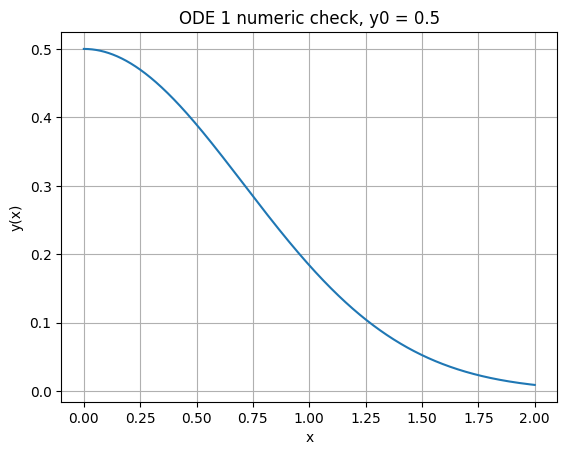

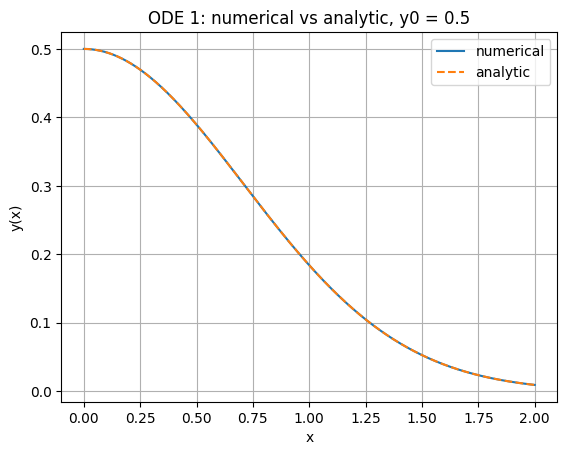

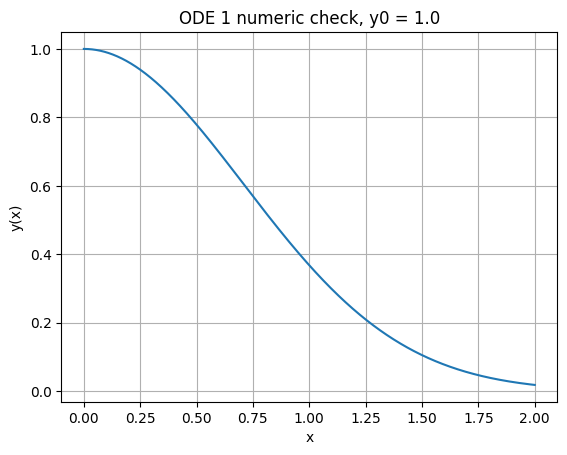

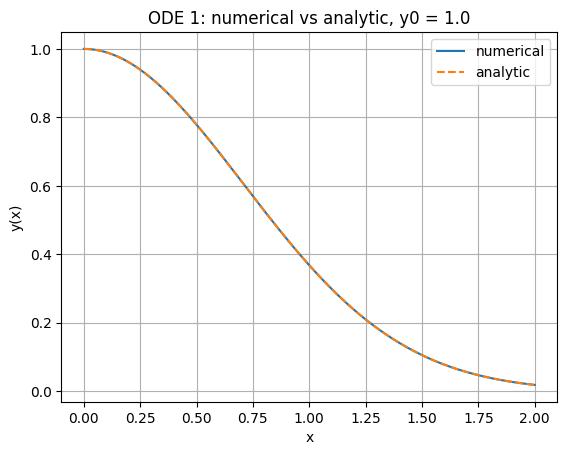

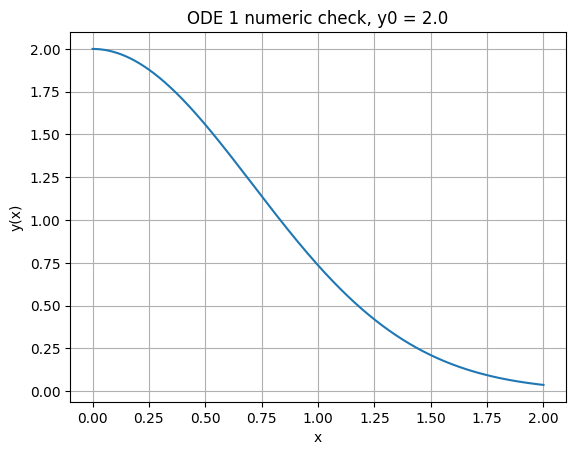

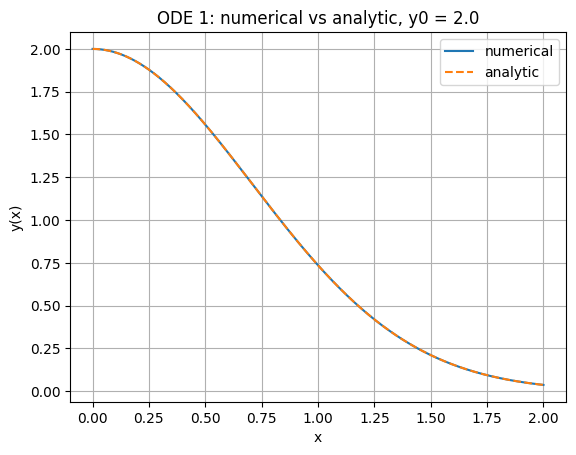

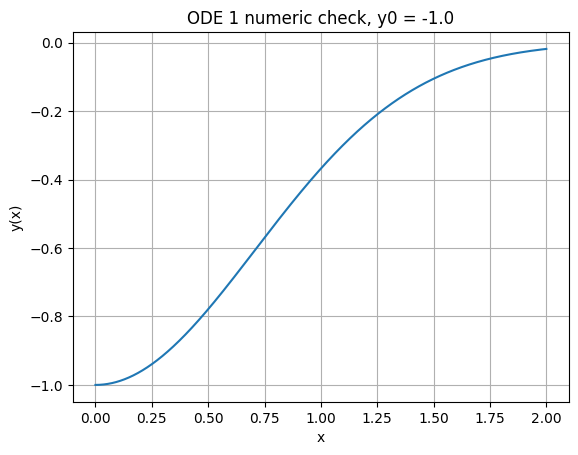

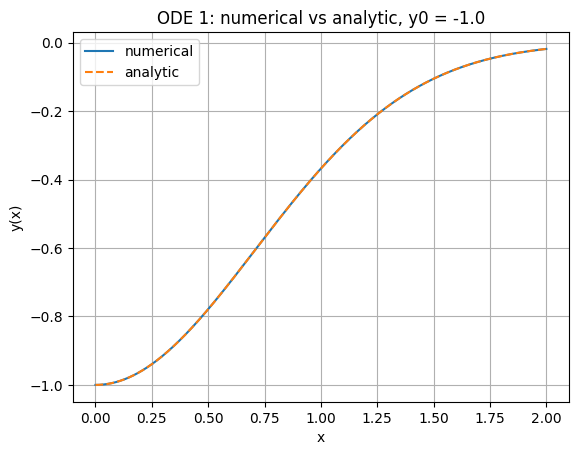


ODE 2
Equation: y' + 2 x y = x,  y(0) = 3/2
Analytic solution: y(x) = 1/2 + exp(-x^2)



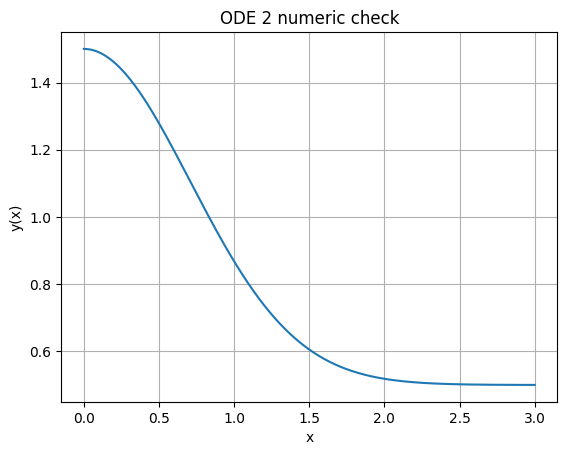

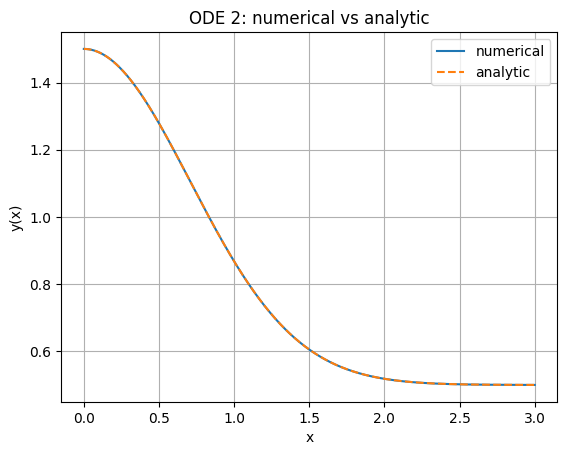


ODE 3
Equation: y'' + 9 y = 18
General analytic solution: y(t) = 2 + C1 cos(3t) + C2 sin(3t)

SymPy dsolve check:
y(t) = C₁⋅sin(3⋅t) + C₂⋅cos(3⋅t) + 2

ODE 4
Equation: y'' + 16 y = 0,  y(0)=1,  y'(0)=4
Analytic solution: y(t) = cos(4t) + sin(4t)

SymPy solution:
y(t) = sin(4⋅t) + cos(4⋅t)


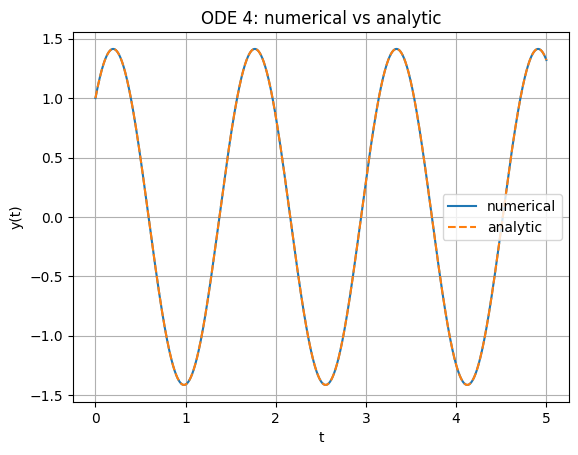


ODE 5 (system)
System:
y1' = 2 y1 + 2 y2
y2' = 5 y1 - y2
y1(0)=0, y2(0)=7
Analytic solution:
y1(t) = 2 exp(4t) - 2 exp(-3t)
y2(t) = 2 exp(4t) + 5 exp(-3t)



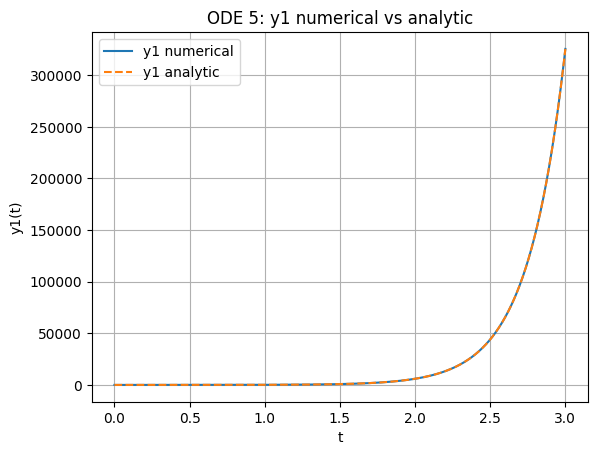

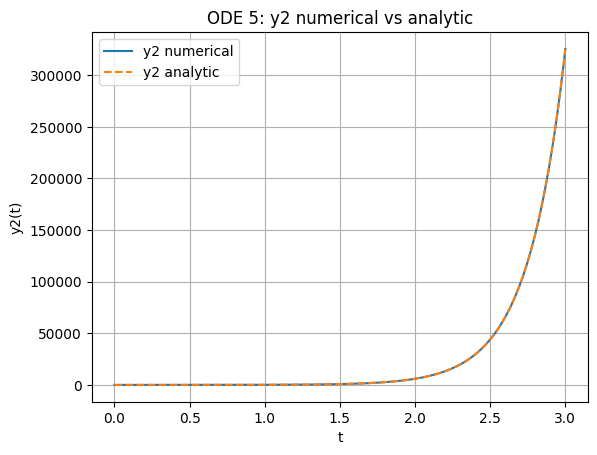

In [ ]:
def solve_plot_first_order(f, y0, xmax=3, npts=1200, title=""):
    x_eval = np.linspace(0, xmax, npts)
    sol = solve_ivp(lambda x, Y: [f(x, Y[0])], (0, xmax), [y0],
                    t_eval=x_eval, rtol=1e-9, atol=1e-12)
    plt.figure()
    plt.plot(sol.t, sol.y[0])
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.title(title)
    plt.grid(True)
    plt.show()
    return sol

print("ODE 1")
print("Equation: y' = -2 x y,  y(0) = y0")
print("Analytic solution: y(x) = y0 * exp(-x^2)\n")

def f1(x, y):
    return -2*x*y

# parameter study of multiple y0
for y0 in [0.5, 1.0, 2.0, -1.0]:
    sol = solve_plot_first_order(f1, y0, xmax=2,
                                title=f"ODE 1 numeric check, y0 = {y0}")
    y_exact = y0 * np.exp(-sol.t**2)
    plt.figure()
    plt.plot(sol.t, sol.y[0], label="numerical")
    plt.plot(sol.t, y_exact, "--", label="analytic")
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.title(f"ODE 1: numerical vs analytic, y0 = {y0}")
    plt.legend()
    plt.grid(True)
    plt.show()

print("\nODE 2")
print("Equation: y' + 2 x y = x,  y(0) = 3/2")
print("Analytic solution: y(x) = 1/2 + exp(-x^2)\n")

def f2(x, y):
    # y' = x - 2 x y
    return x - 2*x*y

y0 = 1.5
sol = solve_plot_first_order(f2, y0, xmax=3, title="ODE 2 numeric check")
y_exact = 0.5 + np.exp(-sol.t**2)

plt.figure()
plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(sol.t, y_exact, "--", label="analytic")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("ODE 2: numerical vs analytic")
plt.legend()
plt.grid(True)
plt.show()

print("\nODE 3")
print("Equation: y'' + 9 y = 18")
print("General analytic solution: y(t) = 2 + C1 cos(3t) + C2 sin(3t)\n")

t = sp.symbols('t', real=True)
y = sp.Function('y')
ode3 = sp.Eq(sp.diff(y(t), t, 2) + 9*y(t), 18)
print("SymPy dsolve check:")
sp.pprint(sp.dsolve(ode3))

print("\nODE 4")
print("Equation: y'' + 16 y = 0,  y(0)=1,  y'(0)=4")
print("Analytic solution: y(t) = cos(4t) + sin(4t)\n")

# symbolic check
y = sp.Function('y')
ode4 = sp.Eq(sp.diff(y(t), t, 2) + 16*y(t), 0)
ics4 = {y(0): 1, sp.diff(y(t), t).subs(t, 0): 4}
sol4 = sp.dsolve(ode4, ics=ics4)
print("SymPy solution:")
sp.pprint(sol4)

# numeric check
def rhs4(tt, Y):
    # Y = [y, v]
    return [Y[1], -16*Y[0]]

tt = np.linspace(0, 5, 2000)
sol_num4 = solve_ivp(rhs4, (0, 5), [1, 4], t_eval=tt, rtol=1e-9, atol=1e-12)

y_exact4 = np.cos(4*tt) + np.sin(4*tt)

plt.figure()
plt.plot(tt, sol_num4.y[0], label="numerical")
plt.plot(tt, y_exact4, "--", label="analytic")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("ODE 4: numerical vs analytic")
plt.legend()
plt.grid(True)
plt.show()

print("\nODE 5 (system)")
print("System:")
print("y1' = 2 y1 + 2 y2")
print("y2' = 5 y1 - y2")
print("y1(0)=0, y2(0)=7")
print("Analytic solution:")
print("y1(t) = 2 exp(4t) - 2 exp(-3t)")
print("y2(t) = 2 exp(4t) + 5 exp(-3t)\n")

A = np.array([[2, 2],
              [5, -1]], dtype=float)

def rhs5(t, Y):
    return (A @ Y)

tt = np.linspace(0, 3, 2000)
sol5 = solve_ivp(rhs5, (0, 3), [0, 7], t_eval=tt, rtol=1e-9, atol=1e-12)

y1_exact = 2*np.exp(4*tt) - 2*np.exp(-3*tt)
y2_exact = 2*np.exp(4*tt) + 5*np.exp(-3*tt)

plt.figure()
plt.plot(tt, sol5.y[0], label="y1 numerical")
plt.plot(tt, y1_exact, "--", label="y1 analytic")
plt.xlabel("t")
plt.ylabel("y1(t)")
plt.title("ODE 5: y1 numerical vs analytic")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(tt, sol5.y[1], label="y2 numerical")
plt.plot(tt, y2_exact, "--", label="y2 analytic")
plt.xlabel("t")
plt.ylabel("y2(t)")
plt.title("ODE 5: y2 numerical vs analytic")
plt.legend()
plt.grid(True)
plt.show()